# Rotation Choices in RBIG
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/rbig/blob/main/docs/notebooks/08_rotation_choices.ipynb)

After each marginal Gaussianization step, RBIG applies a **rotation** to mix
dimensions before the next iteration. The choice of rotation affects
convergence speed and the quality of the learned representation.

This notebook compares the three built-in rotation options:

| Rotation | Class | `AnnealedRBIG` string | Description |
|----------|-------|----------------------|-------------|
| **PCA** | `PCARotation(whiten=False)` | `"pca"` | PCA eigenvector rotation (orthogonal) |
| **ICA** | `ICARotation(orthogonal=True)` | `"ica"` | ICA rotation only — skips whitening (orthogonal) |
| **Random** | `RandomRotation` | `"random"` | Haar-uniform random orthogonal matrix via QR |

All three are **orthogonal** transforms with log|det J| = 0, so they
preserve volume and add no cost to the likelihood computation.

By default, both `PCARotation` and `ICARotation` use their orthogonal modes.
Set `whiten=True` (PCA) or `orthogonal=False` (ICA) to include the
non-orthogonal scaling/whitening step.

For the mathematical properties of rotation matrices (orthogonality, Jacobian, decompositions), see the [Rotation note](../notes/rotation.md).

> **Colab / fresh environment?** Run the cell below to install `rbig` from
> GitHub. Skip if already installed.

In [1]:
!pip install "rbig[all] @ git+https://github.com/jejjohnson/rbig.git" -q

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from rbig import (
    AnnealedRBIG,
    MarginalGaussianize,
    PCARotation,
    ICARotation,
    RandomRotation,
    RBIGLayer,
)

/anaconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

We use the standard 2-D sin-wave dataset.

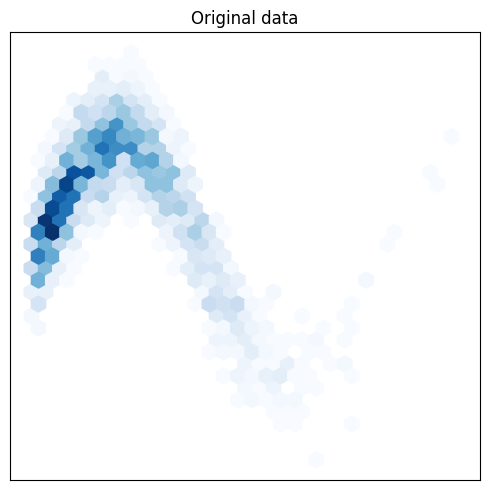

In [3]:
seed = 123
rng = np.random.RandomState(seed=seed)

n_samples = 2_000
x = np.abs(2 * rng.randn(1, n_samples))
y = np.sin(x) + 0.25 * rng.randn(1, n_samples)
data = np.vstack((x, y)).T

fig, ax = plt.subplots(figsize=(5, 5))
ax.hexbin(data[:, 0], data[:, 1], gridsize=30, cmap="Blues", mincnt=1)
ax.set_title("Original data")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

## Single Layer Comparison

Let's see what one RBIG layer looks like with each rotation.

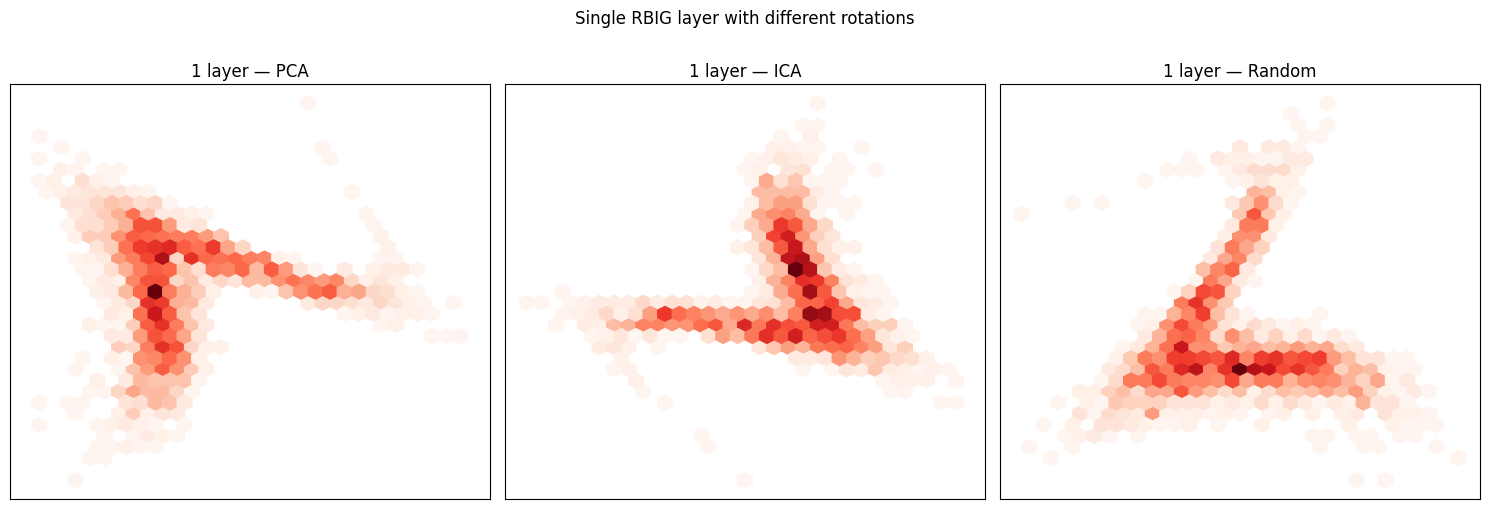

In [4]:
rotations = {
    "PCA": PCARotation(whiten=True),
    "ICA": ICARotation(random_state=seed),
    "Random": RandomRotation(random_state=seed),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, rot) in zip(axes, rotations.items()):
    layer = RBIGLayer(
        marginal=MarginalGaussianize(),
        rotation=rot,
    )
    layer.fit(data)
    Z = layer.transform(data)
    ax.hexbin(Z[:, 0], Z[:, 1], gridsize=30, cmap="Reds", mincnt=1)
    ax.set_title(f"1 layer — {name}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Single RBIG layer with different rotations", y=1.01)
plt.tight_layout()
plt.show()

After just one layer, the outputs already look different:

- **PCA** decorrelates and whitens — the cloud is centred and scaled
- **ICA** looks for statistically independent directions — orientation may differ
- **Random** applies an arbitrary mixing — may or may not reduce dependence in
  one step

## Convergence Comparison

We fit `AnnealedRBIG` with each rotation type and compare:

1. Number of layers needed to converge
2. Total correlation (TC) curve
3. Final reconstruction error

In [5]:
n_layers = 80
patience = 10

models = {}
for name in ["pca", "ica", "random"]:
    model = AnnealedRBIG(
        n_layers=n_layers,
        rotation=name,
        patience=patience,
        random_state=seed,
    )
    model.fit(data)
    models[name] = model
    print(f"{name:>6s}: converged in {len(model.layers_):>2d} layers")

   pca: converged in 27 layers


   ica: converged in 80 layers


random: converged in 80 layers


### TC convergence curves

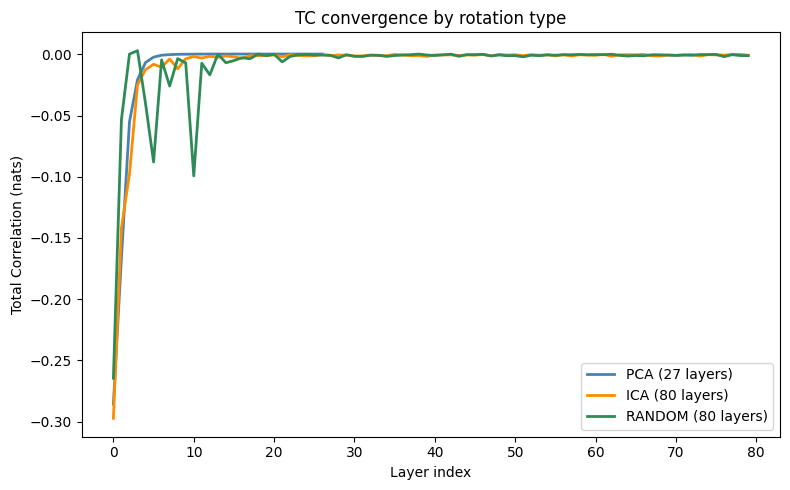

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = {"pca": "steelblue", "ica": "darkorange", "random": "seagreen"}
for name, model in models.items():
    ax.plot(model.tc_per_layer_, label=f"{name.upper()} ({len(model.layers_)} layers)",
            color=colors[name], linewidth=2)

ax.set_xlabel("Layer index")
ax.set_ylabel("Total Correlation (nats)")
ax.set_title("TC convergence by rotation type")
ax.legend()
plt.tight_layout()
plt.show()

### Transformed distributions

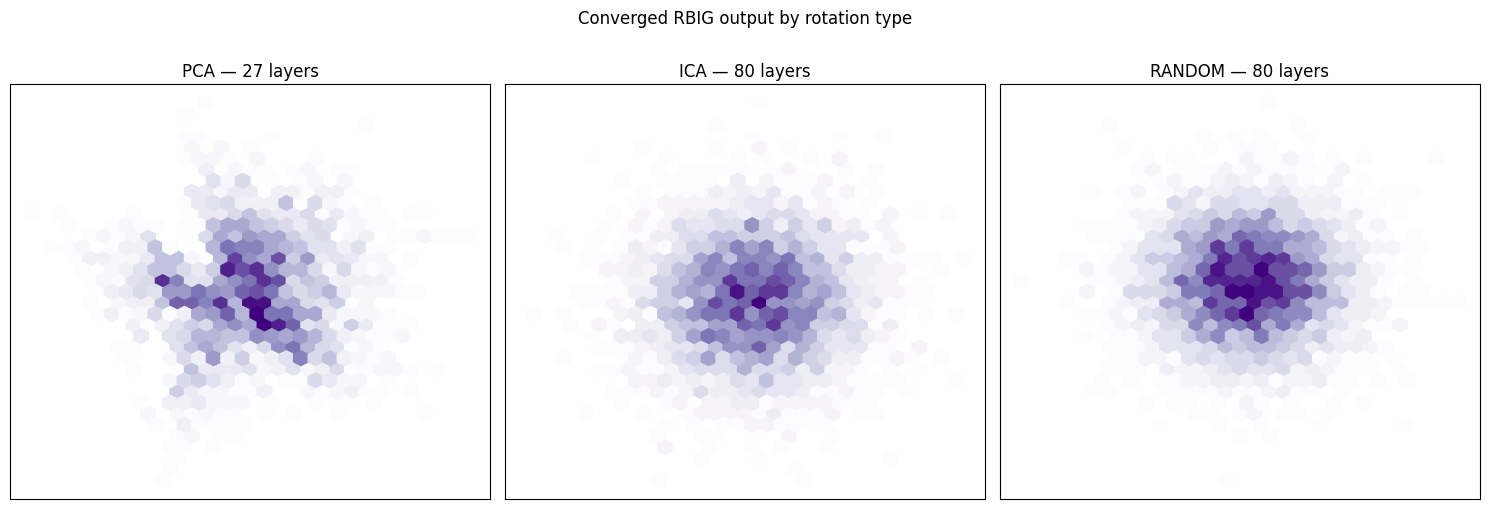

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, model) in zip(axes, models.items()):
    Z = model.transform(data)
    ax.hexbin(Z[:, 0], Z[:, 1], gridsize=30, cmap="Purples", mincnt=1)
    ax.set_title(f"{name.upper()} — {len(model.layers_)} layers")
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Converged RBIG output by rotation type", y=1.01)
plt.tight_layout()
plt.show()

### Reconstruction error

In [8]:
for name, model in models.items():
    Z = model.transform(data)
    data_rec = model.inverse_transform(Z)
    err = np.abs(data - data_rec).mean()
    print(f"{name:>6s}: mean |reconstruction error| = {err:.2e}")

   pca: mean |reconstruction error| = 2.53e-02
   ica: mean |reconstruction error| = 6.28e-02


random: mean |reconstruction error| = 6.10e-02


## Log-Likelihood Comparison

In [9]:
for name, model in models.items():
    ll = model.score(data)
    print(f"{name:>6s}: mean log-likelihood = {ll:.4f}")

   pca: mean log-likelihood = 21.6371


   ica: mean log-likelihood = 88.6146


random: mean log-likelihood = 88.7299


## When to Use Which

| Rotation | Strengths | Best for |
|----------|-----------|----------|
| **PCA** | Fast, deterministic, good default | Most use cases — decorrelation is usually what you want between layers |
| **ICA** | Finds non-Gaussian structure | Data with clear independent sources (e.g., signal separation) |
| **Random** | No data dependence, cheap | Very high-dimensional data where PCA/ICA is expensive; ensemble averaging |

In practice, **PCA is the recommended default**. It tends to converge in
fewer layers because whitening explicitly removes second-order dependence,
leaving only higher-order structure for subsequent layers to handle.

Random rotations may need more layers but are useful when:

- Dimensionality is very high (PCA eigendecomposition is $O(d^3)$)
- You want to average over multiple runs for robust IT estimates

ICA can help when the data has a known independent-source structure, but
it is slower per layer and may not converge faster overall.

## Additional Rotations

Beyond the three main options, `rbig` provides specialized rotation classes
for advanced use cases:

| Class | Use case |
|-------|----------|
| `PicardRotation` | ICA via the Picard algorithm (faster, more robust than FastICA) |
| `RandomOrthogonalProjection` | Semi-orthogonal dimensionality reduction |
| `GaussianRandomProjection` | Johnson-Lindenstrauss style projection |
| `OrthogonalDimensionalityReduction` | Full orthogonal rotation + dimension truncation |
| `DCTRotation` | 2-D Discrete Cosine Transform (image data) |
| `HartleyRotation` | 2-D Discrete Hartley Transform (image data) |
| `RandomChannelRotation` | 1x1 convolution mixing channels (image data) |

These can be passed directly to `RBIGLayer(rotation=...)` for custom
pipelines. See the [API Reference](../api/reference.md) for full signatures.

---
## See Also

- [Rotation Note](../notes/rotation.md) — mathematical properties of rotation matrices in RBIG
- [Image Rotations](./12_image_rotations.ipynb) — specialized rotations for image data (DCT, Hartley, channel mixing)
- [Dimensionality-Reducing Rotations](./13_dimensionality_reduction.ipynb) — rotations that reduce dimensionality